# Non-linear Activations

This notebook explores the non-linear activation functions necessary for our Multilayer Perceptron. These functions introduce non-linearity, allowing the network to learn complex patterns.

**Constraints:** Implemented manually strictly using `numpy`.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## 1. ReLU (Rectified Linear Unit)
**Forward:** $f(z) = \max(0, z)$

**Derivative:** $f'(z) = 1 \text{ if } z > 0 \text{ else } 0$

**Why ReLU?**
ReLU is used primarily in hidden layers to prevent the *vanishing gradient* problem. Unlike sigmoid, its derivative is exactly 1 for all positive inputs, ensuring gradients flow back cleanly without diminishing recursively through the layers.

In [2]:
def relu(z: np.ndarray) -> np.ndarray:
    """
    Forward pass for ReLU.
    Returns the element-wise maximum of 0 and z.

    e.g for z = np.array([-1, 0, 1, 2]), relu(z) will return np.array([0, 0, 1, 2]).
    """
    return np.maximum(0, z)

def relu_prime(z: np.ndarray) -> np.ndarray:
    """
    Backward pass (derivative) for ReLU.
    Used during backpropagation. Returns 1 where z > 0, else 0.

    e.g for z = np.array([-1, 0, 1, 2]), relu_prime(z) will return np.array([0, 0, 1, 1]).

    np.where is used to return an array of the same shape as z, where each element is 1.0 
    if the corresponding element in z is greater than 0, and 0.0 otherwise.
    """
    return np.where(z > 0, 1.0, 0.0)

## 2. Sigmoid
**Forward:** $\sigma(z) = \frac{1}{1 + e^{-z}}$

**Derivative:** $\sigma'(z) = \sigma(z) \cdot (1 - \sigma(z))$

**Why Sigmoid?**
Sigmoid effectively squashes output to a range of (0, 1), making it perfect for interpreting the output layer as a probability for binary classification contexts (like Malignant vs Benign).

In [ ]:
def sigmoid(z: np.ndarray) -> np.ndarray:
    """
    Forward pass for Sigmoid.
    Squashes values to a valid probability distribution [0, 1].
    exp() means e raised to the power of the input.
    For example, exp(0) = 1, exp(1) ≈ 2.71828, and exp(-1) ≈ 0.36788.
    """
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_prime(z: np.ndarray) -> np.ndarray:
    """
    Backward pass (derivative) for Sigmoid.
    Calculated cleanly using the forward output.
    """
    s = sigmoid(z)
    return s * (1.0 - s)

<details>
<summary><strong>Practical Uses: When to Choose Which between ReLu et Sigmoid 💡</strong></summary>

Because of how their derivatives behave, developers place these functions in very specific parts of a neural network.

- **ReLU: The Hidden Layer Workhorse**  
    Because it avoids the vanishing gradient problem for positive numbers and is incredibly fast to calculate (it just turns negative numbers to zero), ReLU is the default choice for the hidden layers (the middle parts) of nearly all modern deep learning models.  
    It allows networks to be stacked dozens or hundreds of layers deep.

- **Sigmoid: The Probability Gate**  
    Since the solid green Sigmoid line smoothly squishes any input number into a range strictly between `0` and `1`, it acts exactly like a probability.  
    Developers use Sigmoid almost exclusively in the final output layer of a network when they need a yes/no answer, like predicting:  
    *"Is this image a cat? (0.95 probability)"*.

</details>

## 3. Softmax
**Stable Forward:** $\sigma(z)_i = \frac{e^{z_i - \max(z)}}{\sum e^{z_j - \max(z)}}$

**Why Softmax?**
It turns a vector of raw logits into a valid multiclass probability distribution summing to 1. Subtracting the maximum of $z$ ensures numeric stability, preventing `np.exp()` from overflowing with large positive logits.

In [ ]:
def softmax(z: np.ndarray) -> np.ndarray:
    """
    Forward pass for Stable Softmax.
    """
    # Subtracting the max z for numeric stability
    # axis=-1 means operate from the beggining up until the last dimension, 
    # keepdims=True keeps the dimensions of the output the same as the input
    shifted_z = z - np.max(z, axis=-1, keepdims=True)
    exp_z = np.exp(shifted_z)
    return exp_z / np.sum(exp_z, axis=-1, keepdims=True)

In [4]:
test_vec = np.array([-2, 0, 2])

In [8]:
shifted_test_vec = test_vec - np.max(test_vec, axis=-1, keepdims=True)

In [ ]:
shifted_test_vec


array([-4, -2,  0])

In [15]:
np.set_printoptions(precision=4, suppress=True)  # Set print options for better readability
# np.exp performs the exponential function element-wise on the input array.
# exponential funtion is defined as e^x, where e is Euler's number (approximately 2.71828).
exp = np.exp(shifted_test_vec)
exp

array([0.0183, 0.1353, 1.    ])

In [12]:
exp / np.sum(exp, axis=-1, keepdims=True)

array([0.01587624, 0.11731043, 0.86681333])

## Visualizations
Let's visually inspect how these functions map their inputs.

In [9]:
# linspace for plotting activation functions and their derivatives
# linspace means to create an array of evenly spaced values over a specified range.
# the goal is to create a smooth curve
# -5 is the lower bound, 5 is the upper bound, and 200 is the number of points to generate between -5 and 5.
z_vals = np.linspace(-5, 5, 200)
print("z_vals:", z_vals)

z_vals: [-5.         -4.94974874 -4.89949749 -4.84924623 -4.79899497 -4.74874372
 -4.69849246 -4.64824121 -4.59798995 -4.54773869 -4.49748744 -4.44723618
 -4.39698492 -4.34673367 -4.29648241 -4.24623116 -4.1959799  -4.14572864
 -4.09547739 -4.04522613 -3.99497487 -3.94472362 -3.89447236 -3.84422111
 -3.79396985 -3.74371859 -3.69346734 -3.64321608 -3.59296482 -3.54271357
 -3.49246231 -3.44221106 -3.3919598  -3.34170854 -3.29145729 -3.24120603
 -3.19095477 -3.14070352 -3.09045226 -3.04020101 -2.98994975 -2.93969849
 -2.88944724 -2.83919598 -2.78894472 -2.73869347 -2.68844221 -2.63819095
 -2.5879397  -2.53768844 -2.48743719 -2.43718593 -2.38693467 -2.33668342
 -2.28643216 -2.2361809  -2.18592965 -2.13567839 -2.08542714 -2.03517588
 -1.98492462 -1.93467337 -1.88442211 -1.83417085 -1.7839196  -1.73366834
 -1.68341709 -1.63316583 -1.58291457 -1.53266332 -1.48241206 -1.4321608
 -1.38190955 -1.33165829 -1.28140704 -1.23115578 -1.18090452 -1.13065327
 -1.08040201 -1.03015075 -0.9798995  -0.9296

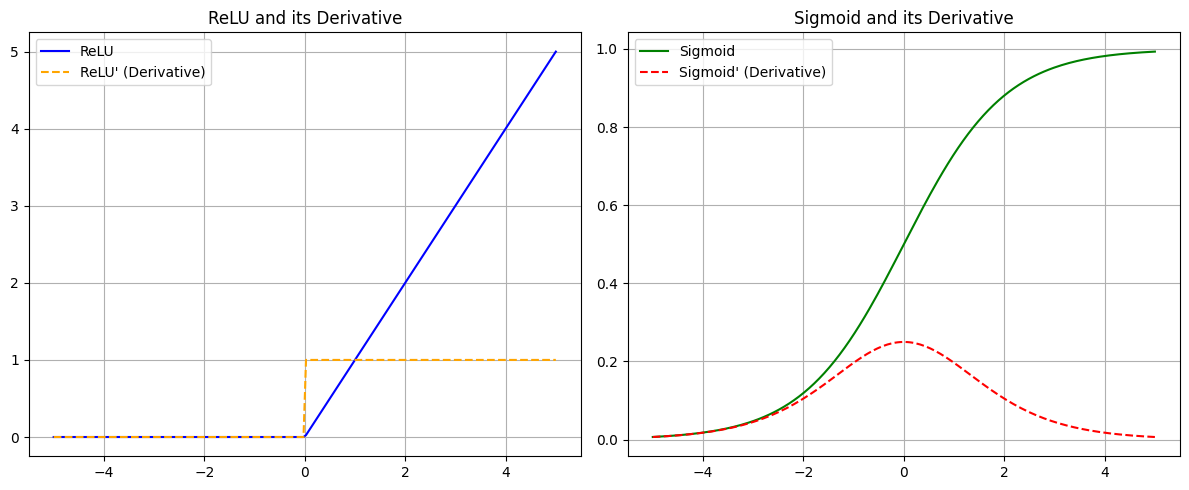

In [8]:

# set up the figure which will contain two subplots:
# one for ReLU and its derivative, and one for Sigmoid and its derivative.
# figsize=(12, 5) means the figure will be 12 inches wide and 5 inches tall.
plt.figure(figsize=(12, 5))

# Subplot 1: ReLU & Derivative
# plt.subplot(1, 2, 1) means we are creating a grid of 1 row and 2 columns of subplots,
# and we are activating the first subplot (the one on the left) to plot ReLU and its derivative.
plt.subplot(1, 2, 1)
plt.plot(z_vals, relu(z_vals), label="ReLU", color='blue')
plt.plot(z_vals, relu_prime(z_vals), label="ReLU' (Derivative)", color='orange', linestyle='dashed')
plt.title("ReLU and its Derivative")
plt.grid(True)
plt.legend()

# Subplot 2: Sigmoid & Derivative
plt.subplot(1, 2, 2)
plt.plot(z_vals, sigmoid(z_vals), label="Sigmoid", color='green')
plt.plot(z_vals, sigmoid_prime(z_vals), label="Sigmoid' (Derivative)", color='red', linestyle='dashed')
plt.title("Sigmoid and its Derivative")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

<details>
<summary><strong>The Role of Derivatives: The Engine of Learning ⚙️</strong></summary>

When a neural network makes a prediction, it compares its output to the correct answer to calculate its **error**.  
To improve, it must adjust internal weights to reduce that error. This is done through **backpropagation**, which depends entirely on **derivatives** (the dashed curves in your plots).

Think of the network as a hiker trying to find the bottom of a valley in dense fog ⛰️.  
The derivative is the local slope under the hiker’s feet: it tells the model which direction to move (toward lower error) and how large the step should be.

### How each activation affects learning

- **Sigmoid Bottleneck (Red Dashed Line):**  
    The derivative peaks at only $0.25$ and quickly shrinks toward zero for very negative or very positive inputs.  
    This creates the **vanishing gradient** problem: the slope becomes nearly flat, so weight updates become tiny and learning can stall.

- **ReLU Highway (Orange Dashed Line):**  
    For positive inputs, the derivative is constant at $1.0$.  
    This preserves a strong gradient signal, allowing the network to keep updating weights effectively even for large activations.

</details>

## Validation Suite
Passing a small numpy array `[-2, 0, 2]` to prove mathematical correctness.

In [6]:
test_vec = np.array([-2.0, 0.0, 2.0])

print("--- Input ---")
print(f"z: {test_vec}\n")

print("--- ReLU ---")
print(f"ReLU(z):       {relu(test_vec)}")
print(f"ReLU_prime(z): {relu_prime(test_vec)}\n")

print("--- Sigmoid ---")
print(f"Sigmoid(z):       {sigmoid(test_vec)}")
print(f"Sigmoid_prime(z): {sigmoid_prime(test_vec)}\n")

print("--- Softmax ---")
print(f"Softmax(z):       {softmax(test_vec)}")
print(f"Sum of Softmax:   {np.sum(softmax(test_vec))}")

--- Input ---
z: [-2.  0.  2.]

--- ReLU ---
ReLU(z):       [0. 0. 2.]
ReLU_prime(z): [0. 0. 1.]

--- Sigmoid ---
Sigmoid(z):       [0.11920292 0.5        0.88079708]
Sigmoid_prime(z): [0.10499359 0.25       0.10499359]

--- Softmax ---
Softmax(z):       [0.01587624 0.11731043 0.86681333]
Sum of Softmax:   1.0
